# PTB-XL ECG Machine Learning Capstone: Clustering Track
## Objective: Unsupervised Discovery of ECG Phenotype Groups

This notebook implements the **Clustering Track** under the Capstone rubric:

1. **Data Preparation**: Same feature matrix as Classification tracks, full dataset (no train/test split — unsupervised).
   Guard-gated median imputation and z-score standardisation applied.
2. **Dimensionality Reduction**: PCA to 2 components for all 2-D visualisations.
3. **K-Means Clustering**
   - Elbow method (WCSS) over $k \in \{2, 3, 4, 5, 6, 7, 8, 9, 10\}$
   - Silhouette scores to confirm optimal $k$
   - Cluster characterisation: mean feature profiles + dominant diagnostic label per cluster
4. **Agglomerative Hierarchical Clustering**
   - Ward linkage with dendrogram (truncated to top 30 merges)
   - Applied at optimal $k$ from K-Means; cluster profiles compared
5. **External Validity**: Cluster purity w.r.t. dominant diagnostic labels, confusion heatmap.


In [27]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
palette = sns.color_palette('tab10')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Clustering libraries loaded.")


Clustering libraries loaded.


---
## Section A: Data Ingestion & Preprocessing


In [28]:
DATA_DIR = '../data'

features_df = pd.read_csv(os.path.join(DATA_DIR, 'stage4_features.csv'))
labels_df   = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_labels.csv'))

label_targets = ['label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP']
df = features_df.merge(
    labels_df[['ecg_id', 'fold'] + label_targets],
    on='ecg_id', how='inner'
)

# Build dominant label for external validity
priority_cols = ['label_MI', 'label_CD', 'label_HYP', 'label_STTC', 'label_NORM']
class_names   = ['MI', 'CD', 'HYP', 'STTC', 'NORM']

def collapse_dominant_label(row):
    for col, name in zip(priority_cols, class_names):
        if row[col] == 1:
            return name
    return 'UNKNOWN'

df['dominant_label'] = df.apply(collapse_dominant_label, axis=1)

print(f"Records: {len(df)} | Labels: {df['dominant_label'].value_counts().to_dict()}")


Records: 21388 | Labels: {'NORM': 9069, 'MI': 5469, 'CD': 3104, 'STTC': 2428, 'HYP': 1318}


In [29]:
# Feature matrix — full dataset (unsupervised, no train/test split needed)
exclude_cols = {'ecg_id', 'patient_id', 'fold', 'dominant_label',
                'label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP'}
feature_cols = [c for c in df.columns if c not in exclude_cols
                and pd.api.types.is_numeric_dtype(df[c])]

if 'qt_mean' in df.columns and 'qrs_dur_mean' in df.columns:
    df['qtc_qrs_ratio'] = df['qt_mean'] / (df['qrs_dur_mean'].replace(0, np.nan))
    if 'qtc_qrs_ratio' not in feature_cols:
        feature_cols.append('qtc_qrs_ratio')

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

X_raw = df[feature_cols].values

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X = scaler.fit_transform(imputer.fit_transform(X_raw))

print(f"Final feature matrix shape: {X.shape}")


Feature columns (26): ['n_beats', 'hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rr_rmssd_ms', 'rr_pnn50', 'n_qrs_reliable', 'frac_qrs_reliable', 'delineation_ok', 'pr_mean_ms', 'pr_std_ms', 'qrs_dur_mean_ms', 'qrs_dur_std_ms', 'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms', 'p_dur_mean_ms', 't_dur_mean_ms', 'p_amp_median_mv', 'r_amp_median_mv', 't_amp_median_mv', 'st_level_median_mv', 'qrs_area_median', 'p_area_median', 't_area_median', 'rs_ratio_median']
Final feature matrix shape: (21388, 26)


---
## Section B: PCA Dimensionality Reduction for Visualisation


PC1 explains 20.7%
PC2 explains 13.5%
Components needed for 90% variance: 14


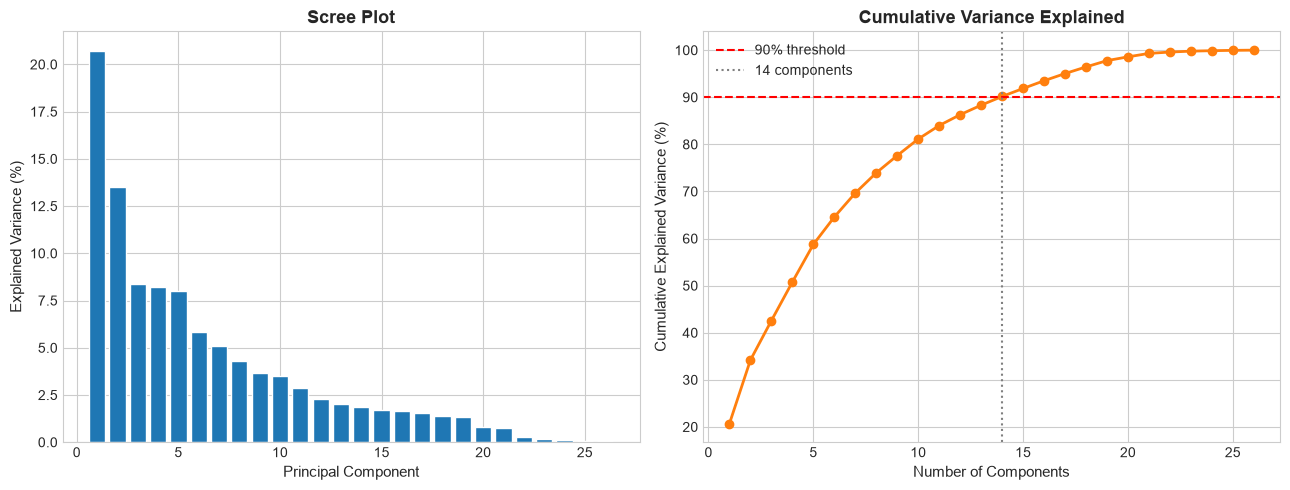

In [30]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE).fit(X)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1

print(f"PC1 explains {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains {pca2.explained_variance_ratio_[1]*100:.1f}%")
print(f"Components needed for 90% variance: {n90}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100, color=palette[0], edgecolor='white')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('Scree Plot', fontsize=13, fontweight='bold')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', color=palette[1], linewidth=2)
axes[1].axhline(90, color='red', linestyle='--', label='90% threshold')
axes[1].axvline(n90, color='grey', linestyle=':', label=f'{n90} components')
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()


---
## Section C: K-Means Clustering

### C.1 — Elbow Method & Silhouette Analysis


In [31]:
K_RANGE = range(2, 11)
wcss        = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=300, random_state=RANDOM_STATE)
    km.fit(X)
    wcss.append(km.inertia_)
    # Use a subsample for silhouette if dataset is large
    sil_sample = min(5000, X.shape[0])
    idx_sample = np.random.choice(X.shape[0], sil_sample, replace=False)
    silhouettes.append(silhouette_score(X[idx_sample], km.labels_[idx_sample]))
    print(f"  k={k:2d}  WCSS={km.inertia_:,.0f}  Silhouette={silhouettes[-1]:.4f}")


  k= 2  WCSS=486,828  Silhouette=0.1233
  k= 3  WCSS=446,971  Silhouette=0.1167
  k= 4  WCSS=421,382  Silhouette=0.1263
  k= 5  WCSS=399,530  Silhouette=0.1050
  k= 6  WCSS=383,926  Silhouette=0.1010
  k= 7  WCSS=371,498  Silhouette=0.0869
  k= 8  WCSS=361,337  Silhouette=0.0881
  k= 9  WCSS=351,772  Silhouette=0.0902
  k=10  WCSS=342,448  Silhouette=0.0758


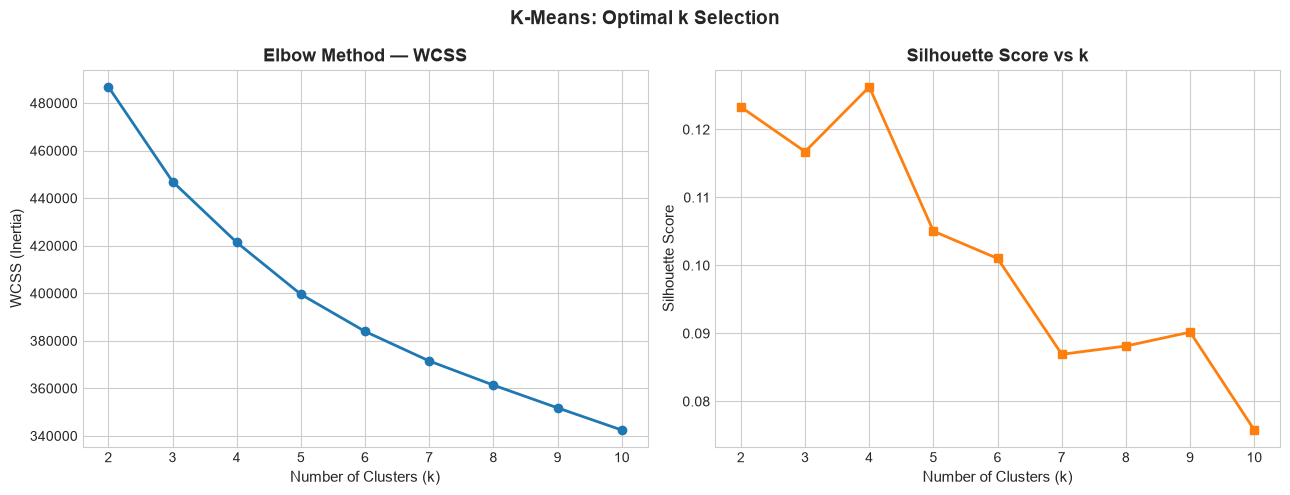

Optimal k by silhouette: 4


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), wcss, marker='o', color=palette[0], linewidth=2)
axes[0].set_xticks(list(K_RANGE))
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=11)
axes[0].set_title('Elbow Method — WCSS', fontsize=13, fontweight='bold')

axes[1].plot(list(K_RANGE), silhouettes, marker='s', color=palette[1], linewidth=2)
axes[1].set_xticks(list(K_RANGE))
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')

plt.suptitle('K-Means: Optimal k Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

OPTIMAL_K = int(np.argmax(silhouettes)) + 2   # offset because K_RANGE starts at 2
print(f"Optimal k by silhouette: {OPTIMAL_K}")


### C.2 — Final K-Means at Optimal k


In [33]:
km_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=50,
                  max_iter=500, random_state=RANDOM_STATE)
km_labels = km_final.fit_predict(X)
df['km_cluster'] = km_labels

print(f"K-Means (k={OPTIMAL_K}) cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index())


K-Means (k=4) cluster sizes:
0    2093
1    2450
2    9393
3    7452
Name: count, dtype: int64


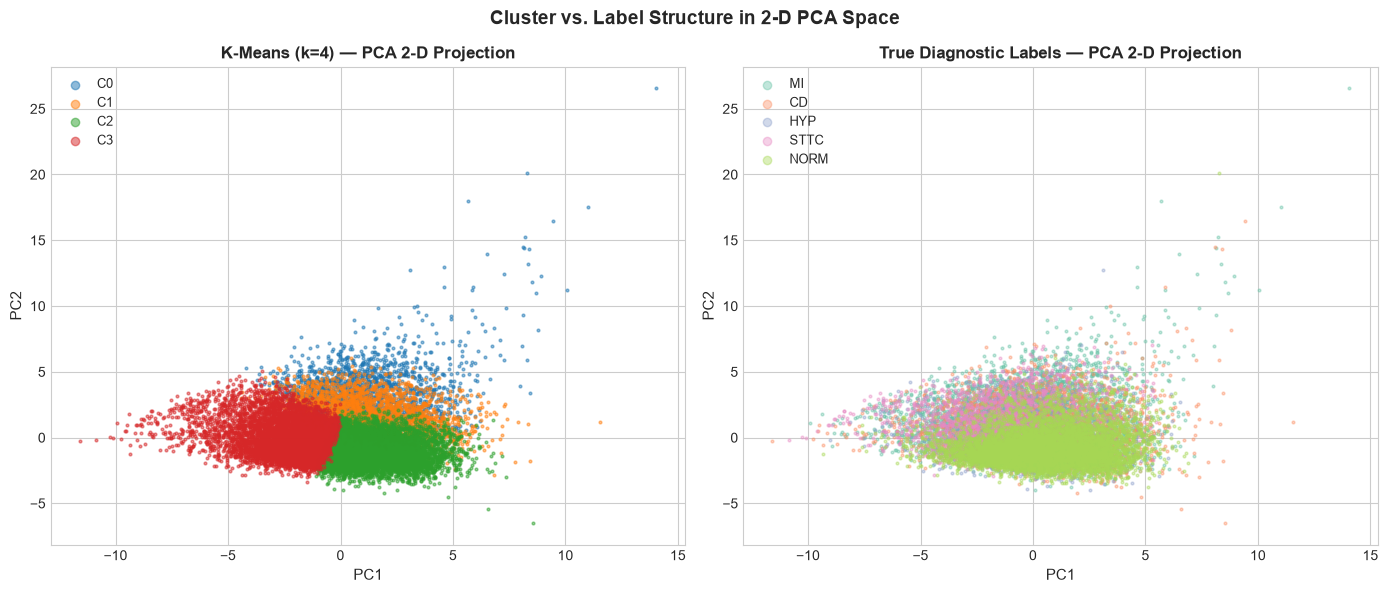

In [34]:
# 2-D scatter: K-Means clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_palette = sns.color_palette('tab10', OPTIMAL_K)
for c in range(OPTIMAL_K):
    mask = km_labels == c
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=4, alpha=0.5, color=cm_palette[c], label=f'C{c}')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].set_title(f'K-Means (k={OPTIMAL_K}) — PCA 2-D Projection', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=3, fontsize=9)

# Colour by dominant diagnostic label
label_palette = {l: c for l, c in zip(class_names, sns.color_palette('Set2', 5))}
for lbl in class_names:
    mask = df['dominant_label'] == lbl
    axes[1].scatter(X_2d[mask.values, 0], X_2d[mask.values, 1],
                    s=4, alpha=0.4, color=label_palette[lbl], label=lbl)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)
axes[1].set_title('True Diagnostic Labels — PCA 2-D Projection', fontsize=12, fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

plt.suptitle('Cluster vs. Label Structure in 2-D PCA Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [35]:
# Cluster profile: mean feature values per K-Means cluster
profile_df = df[feature_cols + ['km_cluster']].groupby('km_cluster').mean()
print("K-Means Cluster Feature Profiles (mean per cluster):")
display(profile_df.T.round(3))


K-Means Cluster Feature Profiles (mean per cluster):


km_cluster,0,1,2,3
n_beats,11.032,11.505,10.411,14.160
hr_bpm,68.983,71.615,64.662,87.981
rr_mean_ms,907.511,869.008,943.241,700.828
rr_std_ms,249.850,52.713,35.111,34.849
rr_rmssd_ms,380.821,72.092,41.668,45.401
rr_pnn50,0.732,0.202,0.128,0.126
n_qrs_reliable,7.407,2.915,9.342,12.697
frac_qrs_reliable,0.674,0.253,0.898,0.902
delineation_ok,0.810,0.001,1.000,0.988
pr_mean_ms,179.167,176.861,173.130,148.291


In [36]:
# Dominant label per cluster (external validity)
cluster_label_counts = (df.groupby(['km_cluster', 'dominant_label'])
                          .size()
                          .unstack(fill_value=0))
# Purity = fraction of majority class
cluster_label_counts['Total']     = cluster_label_counts.sum(axis=1)
cluster_label_counts['Majority']  = cluster_label_counts[class_names].max(axis=1)
cluster_label_counts['Purity']    = (cluster_label_counts['Majority'] /
                                     cluster_label_counts['Total']).round(3)
cluster_label_counts['DomLabel']  = cluster_label_counts[class_names].idxmax(axis=1)

print("K-Means Cluster Purity w.r.t. Diagnostic Labels:")
display(cluster_label_counts)

overall_purity = (cluster_label_counts['Majority'].sum() /
                  cluster_label_counts['Total'].sum())
print(f"Overall K-Means Purity: {overall_purity:.4f}")


K-Means Cluster Purity w.r.t. Diagnostic Labels:


dominant_label,CD,HYP,MI,NORM,STTC,Total,Majority,Purity,DomLabel
km_cluster,,,,,,,,,
0,350,137,938,326,342,2093,938,0.448,MI
1,633,206,716,653,242,2450,716,0.292,MI
2,1149,513,1629,5567,535,9393,5567,0.593,NORM
3,972,462,2186,2523,1309,7452,2523,0.339,NORM


Overall K-Means Purity: 0.4556


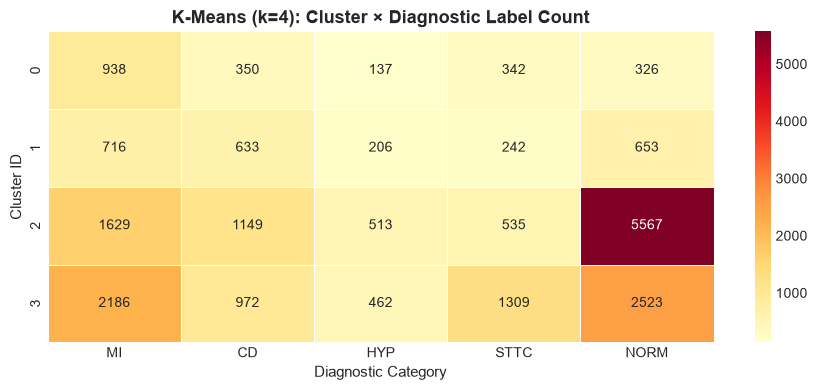

In [37]:
# Heatmap: cluster x label counts
plt.figure(figsize=(9, max(4, OPTIMAL_K)))
sns.heatmap(cluster_label_counts[class_names], annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5)
plt.title(f'K-Means (k={OPTIMAL_K}): Cluster × Diagnostic Label Count',
          fontsize=13, fontweight='bold')
plt.xlabel('Diagnostic Category', fontsize=11)
plt.ylabel('Cluster ID', fontsize=11)
plt.tight_layout()
plt.show()


### C.3 — Non-Linear Manifold Projection (t-SNE)
t-SNE projection performed on a representative subsample ($n=5,000$) to evaluate non-linear cluster separation and alignment with dominant diagnostic phenotypes.


Computing t-SNE projection on subsample (n=5000)...


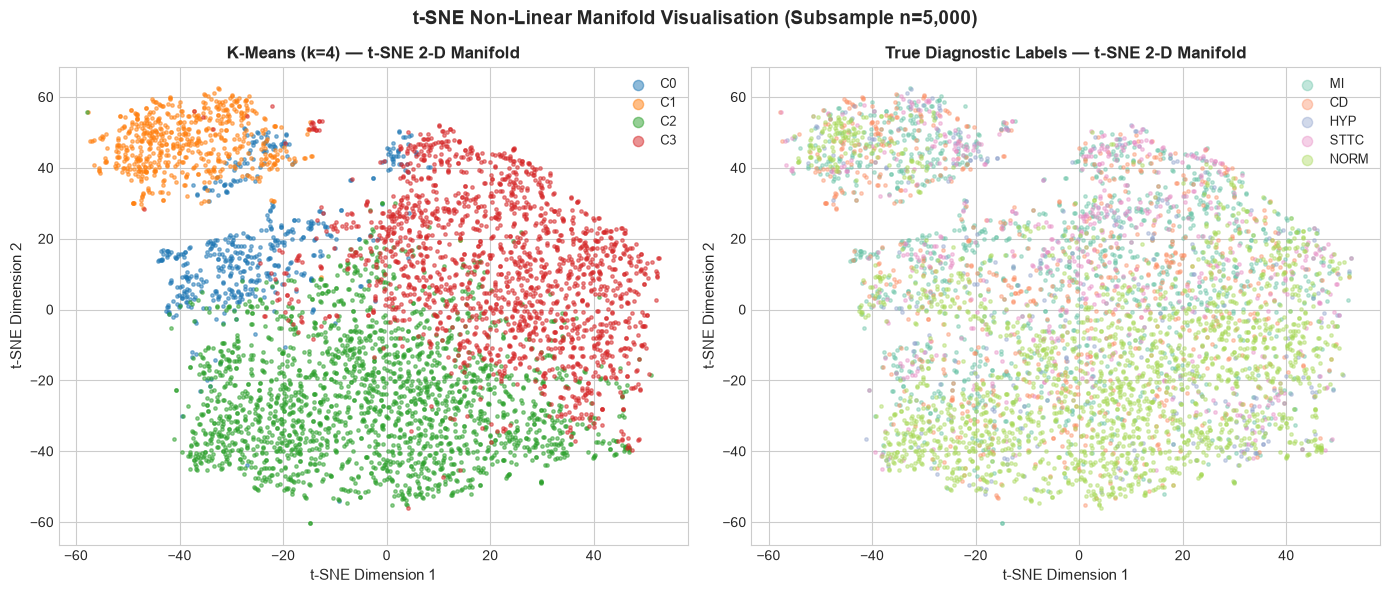

In [38]:
# t-SNE projection (subsampled to 5,000 records for runtime efficiency)
TSNE_SAMPLE = min(5000, X.shape[0])
np.random.seed(RANDOM_STATE)
tsne_idx = np.random.choice(X.shape[0], TSNE_SAMPLE, replace=False)

print(f"Computing t-SNE projection on subsample (n={TSNE_SAMPLE})...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X[tsne_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: K-Means clusters on t-SNE
tsne_km_labels = km_labels[tsne_idx]
for c in range(OPTIMAL_K):
    mask = tsne_km_labels == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=6, alpha=0.5, color=cm_palette[c], label=f'C{c}')
axes[0].set_xlabel('t-SNE Dimension 1', fontsize=11)
axes[0].set_ylabel('t-SNE Dimension 2', fontsize=11)
axes[0].set_title(f'K-Means (k={OPTIMAL_K}) — t-SNE 2-D Manifold', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=3, fontsize=9)

# Subplot 2: True diagnostic labels on t-SNE
tsne_true_labels = df['dominant_label'].iloc[tsne_idx].values
for lbl in class_names:
    mask = tsne_true_labels == lbl
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=6, alpha=0.4, color=label_palette[lbl], label=lbl)
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=11)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=11)
axes[1].set_title('True Diagnostic Labels — t-SNE 2-D Manifold', fontsize=12, fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

plt.suptitle('t-SNE Non-Linear Manifold Visualisation (Subsample n=5,000)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section D: Agglomerative Hierarchical Clustering (Ward Linkage)

### D.1 — Dendrogram


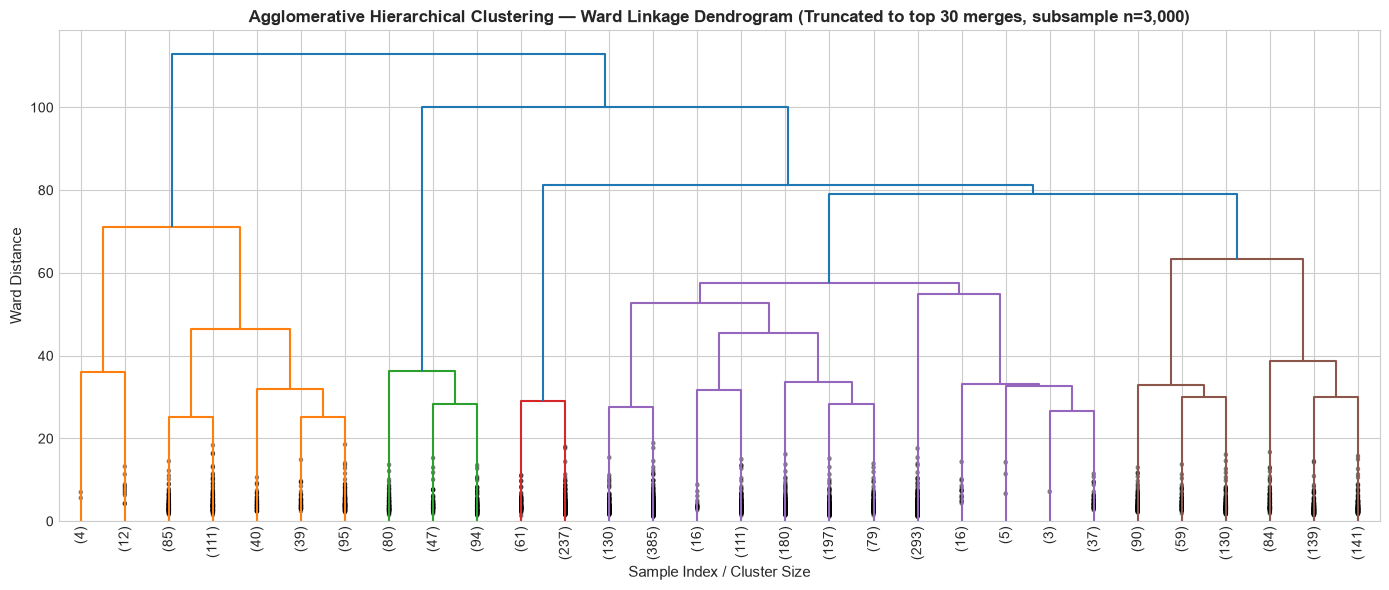

In [39]:
# Compute linkage on a subsample for the dendrogram (ward on full N×N is expensive)
DENDRO_SAMPLE = min(3000, X.shape[0])
np.random.seed(RANDOM_STATE)
didx = np.random.choice(X.shape[0], DENDRO_SAMPLE, replace=False)
Z = linkage(X[didx], method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           show_contracted=True, ax=ax, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Agglomerative Hierarchical Clustering — Ward Linkage Dendrogram (Truncated to top 30 merges, subsample n=3,000)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sample Index / Cluster Size', fontsize=11)
ax.set_ylabel('Ward Distance', fontsize=11)
plt.tight_layout()
plt.show()


### D.2 — Agglomerative at Optimal k


In [40]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X)
df['agg_cluster'] = agg_labels

print(f"Agglomerative (k={OPTIMAL_K}) cluster sizes:")
print(pd.Series(agg_labels).value_counts().sort_index())


Agglomerative (k=4) cluster sizes:
0     7368
1     1223
2    10182
3     2615
Name: count, dtype: int64


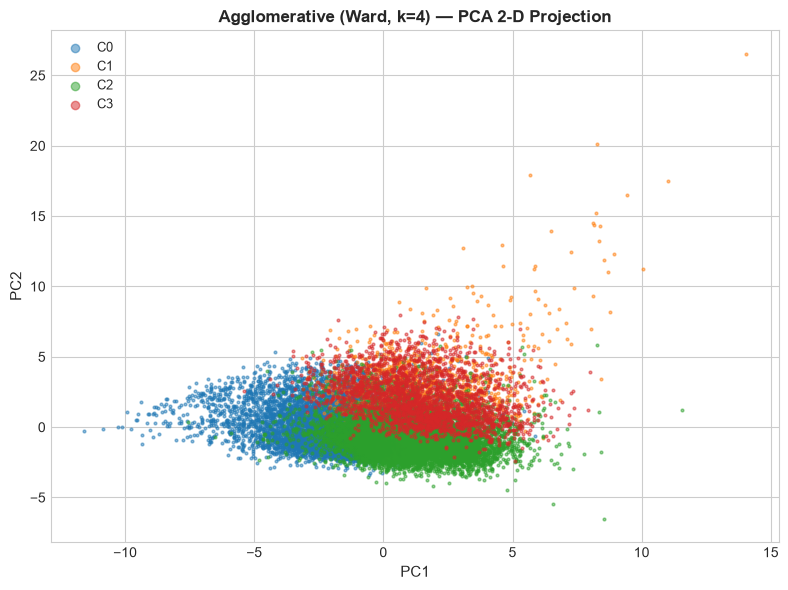

In [41]:
# 2-D PCA scatter: Agglomerative clusters
fig, ax = plt.subplots(figsize=(8, 6))
agg_palette = sns.color_palette('tab10', OPTIMAL_K)
for c in range(OPTIMAL_K):
    mask = agg_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=4, alpha=0.5, color=agg_palette[c], label=f'C{c}')
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title(f'Agglomerative (Ward, k={OPTIMAL_K}) — PCA 2-D Projection',
             fontsize=12, fontweight='bold')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()


In [42]:
# External validity: Agglomerative purity
agg_label_counts = (df.groupby(['agg_cluster', 'dominant_label'])
                      .size()
                      .unstack(fill_value=0))
agg_label_counts['Total']    = agg_label_counts.sum(axis=1)
agg_label_counts['Majority'] = agg_label_counts[class_names].max(axis=1)
agg_label_counts['Purity']   = (agg_label_counts['Majority'] /
                                 agg_label_counts['Total']).round(3)
agg_label_counts['DomLabel'] = agg_label_counts[class_names].idxmax(axis=1)

print("Agglomerative Cluster Purity w.r.t. Diagnostic Labels:")
display(agg_label_counts)

agg_purity = (agg_label_counts['Majority'].sum() / agg_label_counts['Total'].sum())
print(f"Overall Agglomerative Purity: {agg_purity:.4f}")


Agglomerative Cluster Purity w.r.t. Diagnostic Labels:


dominant_label,CD,HYP,MI,NORM,STTC,Total,Majority,Purity,DomLabel
agg_cluster,,,,,,,,,
0,894,421,2257,2511,1285,7368,2511,0.341,NORM
1,219,81,498,270,155,1223,498,0.407,MI
2,1424,616,1862,5599,681,10182,5599,0.550,NORM
3,567,200,852,689,307,2615,852,0.326,MI


Overall Agglomerative Purity: 0.4423


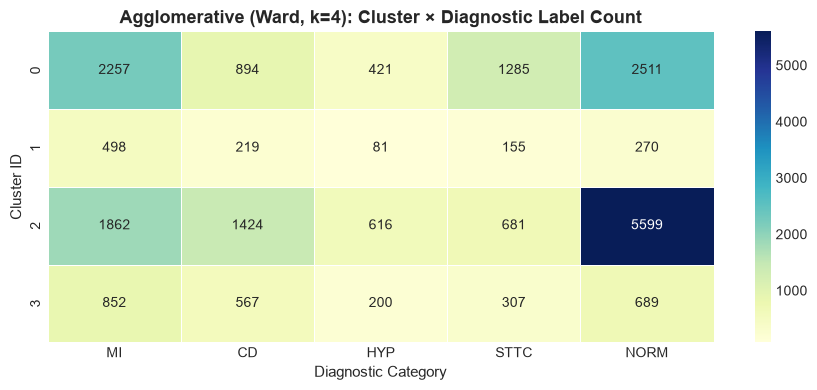

In [43]:
# Heatmap: Agglomerative cluster x label
plt.figure(figsize=(9, max(4, OPTIMAL_K)))
sns.heatmap(agg_label_counts[class_names], annot=True, fmt='d',
            cmap='YlGnBu', linewidths=0.5)
plt.title(f'Agglomerative (Ward, k={OPTIMAL_K}): Cluster × Diagnostic Label Count',
          fontsize=13, fontweight='bold')
plt.xlabel('Diagnostic Category', fontsize=11)
plt.ylabel('Cluster ID', fontsize=11)
plt.tight_layout()
plt.show()


---
## Section E: Summary Comparison — K-Means vs Agglomerative


In [44]:
# Metrics evaluation: Silhouette on subsample; DB & CH on full matrix X
km_sil  = silhouette_score(X, km_labels, sample_size=min(5000, len(X)), random_state=RANDOM_STATE)
agg_sil = silhouette_score(X, agg_labels, sample_size=min(5000, len(X)), random_state=RANDOM_STATE)

km_db  = davies_bouldin_score(X, km_labels)
agg_db = davies_bouldin_score(X, agg_labels)

km_ch  = calinski_harabasz_score(X, km_labels)
agg_ch = calinski_harabasz_score(X, agg_labels)

summary = pd.DataFrame({
    'Method':              ['K-Means', 'Agglomerative (Ward)'],
    'k':                   [OPTIMAL_K, OPTIMAL_K],
    'Silhouette Score':    [round(km_sil, 4),   round(agg_sil, 4)],
    'Davies-Bouldin':      [round(km_db, 4),    round(agg_db, 4)],
    'Calinski-Harabasz':   [round(km_ch, 2),    round(agg_ch, 2)],
    'Overall Purity':      [round(overall_purity, 4), round(agg_purity, 4)],
})

print("=" * 75)
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 75)
display(summary)


CLUSTERING ALGORITHM COMPARISON


,Method,k,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Overall Purity
0,K-Means,4,0.1274,2.0596,2278.66,0.4556
1,Agglomerative (Ward),4,0.0940,2.3553,1688.93,0.4423



> **Metric Interpretation Guide**:
> - **Silhouette Score**: Higher is better (range $[-1, +1]$). Measures within-cluster cohesion versus separation from neighboring clusters.
> - **Davies-Bouldin Index**: Lower is better ($\ge 0$). Measures average similarity ratio between each cluster and its most similar one; lower indicates tighter clusters with greater mutual separation.
> - **Calinski-Harabasz Index**: Higher is better. Variance ratio criterion measuring between-cluster dispersion relative to within-cluster dispersion.
> - **Overall Purity**: Higher is better ($[0, 1]$). Evaluates agreement between unsupervised phenotype clusters and supervised clinical diagnoses ($\text{Purity} = \sum_k \max_j |c_k \cap \omega_j| / N$).


---
## References & Citations
1. Wagner, P., et al. (2020). *PTB-XL, a large publicly available electrocardiography dataset*. Scientific Data, 7(1), 154.
2. MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proc. 5th Berkeley Symposium, 1, 281-297.
3. Ward, J. H. (1963). *Hierarchical grouping to optimize an objective function*. JASA, 58(301), 236-244.
4. Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. JCAM, 20, 53-65.
5. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825-2830.
